In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

print("Imports successful.")

Imports successful.


In [2]:
PROJECT_DIR = Path.cwd().parent

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_DIR / "results"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project directory:")
print(PROJECT_DIR)

print("\nResults directory:")
print(RESULTS_DIR)

Project directory:
c:\Users\ASUS\Documents\Smart-Tourism-Recommendation

Results directory:
c:\Users\ASUS\Documents\Smart-Tourism-Recommendation\results


In [3]:
destinations_path = (
    PROCESSED_DIR /
    "destinations_clean.csv"
)

destinations = pd.read_csv(
    destinations_path
)

print("Destinations loaded.")
print("Shape:", destinations.shape)

display(destinations.head())

Destinations loaded.
Shape: (100, 21)


,destination_id,name,district,latitude,longitude,category,estimated_cost_lkr,duration_hours,interest_tags,sustainability_score,...,seasonality_score,sentiment_nature,sentiment_service,sentiment_value,weather_temp_c,weather_rain_risk,weather_suitability,source_provenance,data_status,num_interest_tags
0,D001,Sigiriya Rock Fortress,matale,7.9570,80.7603,heritage;nature,12000,3.0,heritage;history;photography;hiking,57,...,58,0.699,0.774,0.675,25.1,0.484,0.516,Research-seed record: destination name/locatio...,real_destination_synthetic_attributes,1
1,D002,Dambulla Cave Temple,matale,7.8567,80.6492,heritage,5000,2.0,heritage;history;culture;photography,55,...,47,0.727,0.864,0.910,28.9,0.246,0.754,Research-seed record: destination name/locatio...,real_destination_synthetic_attributes,1
2,D003,Minneriya National Park,polonnaruwa,8.0352,80.8767,wildlife;nature,15000,4.0,wildlife;photography;nature;adventure,70,...,59,0.745,0.866,0.705,24.1,0.618,0.382,Research-seed record: destination name/locatio...,real_destination_synthetic_attributes,1
3,D004,Kaudulla National Park,polonnaruwa,8.0770,80.9630,wildlife;nature,15000,4.0,wildlife;photography;nature;adventure,64,...,66,0.619,0.639,0.610,28.4,0.634,0.366,Research-seed record: destination name/locatio...,real_destination_synthetic_attributes,1
4,D005,Polonnaruwa Ancient City,polonnaruwa,7.9403,81.0188,heritage,5000,4.0,heritage;history;culture;photography,58,...,62,0.785,0.943,0.652,27.1,0.533,0.467,Research-seed record: destination name/locatio...,real_destination_synthetic_attributes,1


In [4]:
print("Destination columns:")
print(destinations.columns.tolist())

Destination columns:
['destination_id', 'name', 'district', 'latitude', 'longitude', 'category', 'estimated_cost_lkr', 'duration_hours', 'interest_tags', 'sustainability_score', 'crowd_score', 'seasonality_score', 'sentiment_nature', 'sentiment_service', 'sentiment_value', 'weather_temp_c', 'weather_rain_risk', 'weather_suitability', 'source_provenance', 'data_status', 'num_interest_tags']


In [5]:
print("Crowd score statistics:")

print(
    destinations["crowd_score"].describe()
)


Crowd score statistics:
count    100.000000
mean      33.380000
std        5.292991
min       21.000000
25%       29.750000
50%       33.500000
75%       37.000000
max       45.000000
Name: crowd_score, dtype: float64


In [6]:
print(
    "Minimum crowd score:",
    destinations["crowd_score"].min()
)

print(
    "Maximum crowd score:",
    destinations["crowd_score"].max()
)

print(
    "Mean crowd score:",
    destinations["crowd_score"].mean()
)

Minimum crowd score: 21
Maximum crowd score: 45
Mean crowd score: 33.38


In [7]:
def classify_crowd(score):
    if score < 33:
        return "Low"
    elif score < 67:
        return "Medium"
    else:
        return "High"


destinations["crowd_level"] = (
    destinations["crowd_score"]
    .apply(classify_crowd)
)

print(
    destinations[
        [
            "destination_id",
            "name",
            "crowd_score",
            "crowd_level"
        ]
    ].head(15)
)

   destination_id                       name  crowd_score crowd_level
0            D001     Sigiriya Rock Fortress           41      Medium
1            D002       Dambulla Cave Temple           41      Medium
2            D003    Minneriya National Park           35      Medium
3            D004     Kaudulla National Park           33      Medium
4            D005   Polonnaruwa Ancient City           32         Low
5            D006   Anuradhapura Sacred City           29         Low
6            D007         Ritigala Monastery           29         Low
7            D008                  Mihintale           37      Medium
8            D009     Wilpattu National Park           28         Low
9            D010                Jaffna Fort           30         Low
10           D011    Nallur Kandaswamy Kovil           44      Medium
11           D012            Casuarina Beach           43      Medium
12           D013               Delft Island           36      Medium
13           D014  K

In [8]:
print("Crowd level distribution:")

display(
    destinations["crowd_level"]
    .value_counts()
)

Crowd level distribution:


crowd_level
Medium    56
Low       44
Name: count, dtype: int64

In [9]:
display(
    destinations["crowd_level"]
    .value_counts(
        normalize=True
    )
)

crowd_level
Medium    0.56
Low       0.44
Name: proportion, dtype: float64

In [10]:
feature_columns = [
    "estimated_cost_lkr",
    "sustainability_score",
    "seasonality_score",
    "weather_temp_c",
    "weather_rain_risk"
]

print("Feature columns:")
print(feature_columns)

print("\nMissing values:")

print(
    destinations[
        feature_columns
    ].isna().sum()
)

Feature columns:
['estimated_cost_lkr', 'sustainability_score', 'seasonality_score', 'weather_temp_c', 'weather_rain_risk']

Missing values:
estimated_cost_lkr      0
sustainability_score    0
seasonality_score       0
weather_temp_c          0
weather_rain_risk       0
dtype: int64


In [11]:
X = destinations[
    feature_columns
].copy()

y = destinations[
    "crowd_score"
].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 5)
y shape: (100,)


In [13]:
FEATURES = [
    "estimated_cost_lkr",
    "sustainability_score",
    "seasonality_score",
    "weather_temp_c",
    "weather_rain_risk"
]

X = destinations[FEATURES].copy()
y = destinations["crowd_score"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

X shape: (100, 5)
y shape: (100,)

Features:
['estimated_cost_lkr', 'sustainability_score', 'seasonality_score', 'weather_temp_c', 'weather_rain_risk']


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (80, 5)
X_test : (20, 5)
y_train: (80,)
y_test : (20,)


In [15]:
print("X_train exists:", "X_train" in globals())
print("X_test exists :", "X_test" in globals())
print("y_train exists:", "y_train" in globals())
print("y_test exists :", "y_test" in globals())

X_train exists: True
X_test exists : True
y_train exists: True
y_test exists : True


In [16]:
from sklearn.ensemble import RandomForestRegressor

crowd_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=8,
    min_samples_leaf=2
)

crowd_model.fit(
    X_train,
    y_train
)

print("Random Forest crowd prediction model trained successfully.")

Random Forest crowd prediction model trained successfully.


In [17]:
# Cell 13 — Predict crowd scores on test data

y_pred = crowd_model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

print("\nPrediction range:")
print("Minimum:", y_pred.min())
print("Maximum:", y_pred.max())
print("Mean:", y_pred.mean())

Predictions generated successfully.
Number of predictions: 20

Prediction range:
Minimum: 30.240530403213924
Maximum: 35.36520805498138
Mean: 32.1711785076737


In [18]:
# Cell 14 — Evaluate crowd prediction model

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("========== CROWD MODEL EVALUATION ==========")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

========== CROWD MODEL EVALUATION ==========
MAE : 4.4381489918740105
RMSE: 5.611241235056877
R²  : -0.3490157754071388


In [19]:
# Cell 15 — Actual vs predicted crowd scores

comparison = pd.DataFrame({
    "actual_crowd_score": y_test.values,
    "predicted_crowd_score": y_pred
})

comparison["absolute_error"] = (
    comparison["actual_crowd_score"]
    - comparison["predicted_crowd_score"]
).abs()

display(comparison.head(20))

,actual_crowd_score,predicted_crowd_score,absolute_error
0,35,31.652077,3.347923
1,37,31.827333,5.172667
2,33,33.550114,0.550114
3,40,32.643275,7.356725
4,42,30.326711,11.673289
5,30,32.649231,2.649231
6,30,31.513454,1.513454
7,45,34.565597,10.434403
8,44,35.365208,8.634792
9,41,32.394013,8.605987


In [20]:
# Cell 16 — Feature importance

feature_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": crowd_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

display(feature_importance)

,feature,importance
3,weather_temp_c,0.363405
4,weather_rain_risk,0.227130
1,sustainability_score,0.159046
2,seasonality_score,0.136193
0,estimated_cost_lkr,0.114225


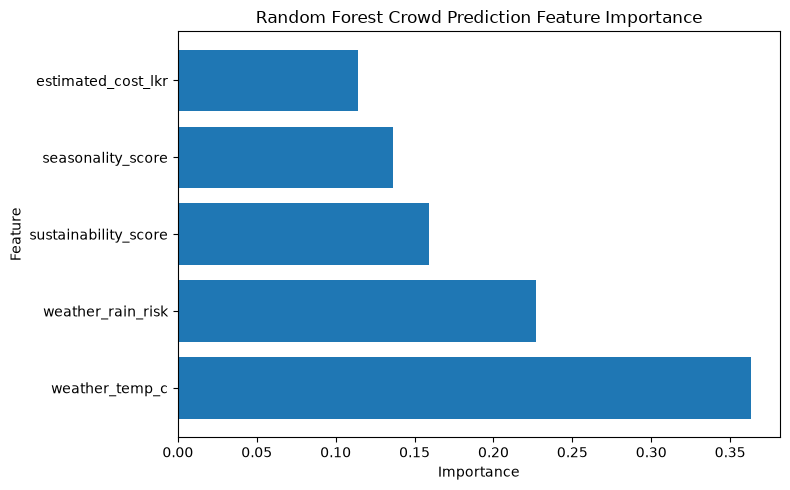

In [21]:
# Cell 17 — Feature importance plot

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Crowd Prediction Feature Importance")

plt.tight_layout()
plt.show()

In [22]:
# Cell 18 — Predict crowd score for all destinations

destinations["predicted_crowd_score"] = crowd_model.predict(
    destinations[FEATURES]
)

print("Predictions generated for all destinations.")

print(
    destinations[
        [
            "destination_id",
            "name",
            "crowd_score",
            "predicted_crowd_score"
        ]
    ].head(10)
)

Predictions generated for all destinations.
  destination_id                      name  crowd_score  predicted_crowd_score
0           D001    Sigiriya Rock Fortress           41              32.394013
1           D002      Dambulla Cave Temple           41              38.124604
2           D003   Minneriya National Park           35              35.323948
3           D004    Kaudulla National Park           33              33.004178
4           D005  Polonnaruwa Ancient City           32              31.190871
5           D006  Anuradhapura Sacred City           29              30.234715
6           D007        Ritigala Monastery           29              30.390418
7           D008                 Mihintale           37              34.405824
8           D009    Wilpattu National Park           28              31.886878
9           D010               Jaffna Fort           30              32.852579


In [23]:
# Cell 19 — Convert predicted crowd score to category

def classify_predicted_crowd(score):
    if score < 33:
        return "Low"
    elif score < 67:
        return "Medium"
    else:
        return "High"


destinations["predicted_crowd_level"] = (
    destinations["predicted_crowd_score"]
    .apply(classify_predicted_crowd)
)

display(
    destinations[
        [
            "destination_id",
            "name",
            "crowd_score",
            "predicted_crowd_score",
            "predicted_crowd_level"
        ]
    ].head(15)
)

,destination_id,name,crowd_score,predicted_crowd_score,predicted_crowd_level
0,D001,Sigiriya Rock Fortress,41,32.394013,Low
1,D002,Dambulla Cave Temple,41,38.124604,Medium
2,D003,Minneriya National Park,35,35.323948,Medium
3,D004,Kaudulla National Park,33,33.004178,Medium
4,D005,Polonnaruwa Ancient City,32,31.190871,Low
5,D006,Anuradhapura Sacred City,29,30.234715,Low
6,D007,Ritigala Monastery,29,30.390418,Low
7,D008,Mihintale,37,34.405824,Medium
8,D009,Wilpattu National Park,28,31.886878,Low
9,D010,Jaffna Fort,30,32.852579,Low


In [24]:
# Cell 20 — Prediction range check

print("========== PREDICTED CROWD CHECK ==========")

print(
    "Minimum:",
    destinations["predicted_crowd_score"].min()
)

print(
    "Maximum:",
    destinations["predicted_crowd_score"].max()
)

print(
    "Mean:",
    destinations["predicted_crowd_score"].mean()
)

print("\nPredicted crowd levels:")

print(
    destinations["predicted_crowd_level"]
    .value_counts()
)

========== PREDICTED CROWD CHECK ==========
Minimum: 27.644583333333333
Maximum: 38.8621278998779
Mean: 32.75070731670903

Predicted crowd levels:
predicted_crowd_level
Low       54
Medium    46
Name: count, dtype: int64


In [25]:
# Cell 21 — Full destination comparison

crowd_comparison = destinations[
    [
        "destination_id",
        "name",
        "crowd_score",
        "predicted_crowd_score",
        "predicted_crowd_level"
    ]
].copy()

crowd_comparison["prediction_difference"] = (
    crowd_comparison["predicted_crowd_score"]
    - crowd_comparison["crowd_score"]
)

crowd_comparison["absolute_error"] = (
    crowd_comparison["prediction_difference"]
    .abs()
)

display(
    crowd_comparison.head(20)
)

,destination_id,name,crowd_score,predicted_crowd_score,predicted_crowd_level,prediction_difference,absolute_error
0,D001,Sigiriya Rock Fortress,41,32.394013,Low,-8.605987,8.605987
1,D002,Dambulla Cave Temple,41,38.124604,Medium,-2.875396,2.875396
2,D003,Minneriya National Park,35,35.323948,Medium,0.323948,0.323948
3,D004,Kaudulla National Park,33,33.004178,Medium,0.004178,0.004178
4,D005,Polonnaruwa Ancient City,32,31.190871,Low,-0.809129,0.809129
5,D006,Anuradhapura Sacred City,29,30.234715,Low,1.234715,1.234715
6,D007,Ritigala Monastery,29,30.390418,Low,1.390418,1.390418
7,D008,Mihintale,37,34.405824,Medium,-2.594176,2.594176
8,D009,Wilpattu National Park,28,31.886878,Low,3.886878,3.886878
9,D010,Jaffna Fort,30,32.852579,Low,2.852579,2.852579


In [26]:
# Cell 22 — Full dataset evaluation

full_mae = mean_absolute_error(
    destinations["crowd_score"],
    destinations["predicted_crowd_score"]
)

full_rmse = np.sqrt(
    mean_squared_error(
        destinations["crowd_score"],
        destinations["predicted_crowd_score"]
    )
)

print("Full dataset MAE :", full_mae)
print("Full dataset RMSE:", full_rmse)

Full dataset MAE : 2.8480310255061223
Full dataset RMSE: 3.626906356193844


In [27]:
# Cell 23 — Final crowd prediction dataset

crowd_output = destinations[
    [
        "destination_id",
        "name",
        "category",
        "district",
        "estimated_cost_lkr",
        "sustainability_score",
        "crowd_score",
        "predicted_crowd_score",
        "predicted_crowd_level",
        "seasonality_score",
        "weather_temp_c",
        "weather_rain_risk",
        "weather_suitability"
    ]
].copy()

print("Final crowd output shape:")
print(crowd_output.shape)

display(crowd_output.head(10))

Final crowd output shape:
(100, 13)


,destination_id,name,category,district,estimated_cost_lkr,sustainability_score,crowd_score,predicted_crowd_score,predicted_crowd_level,seasonality_score,weather_temp_c,weather_rain_risk,weather_suitability
0,D001,Sigiriya Rock Fortress,heritage;nature,matale,12000,57,41,32.394013,Low,58,25.1,0.484,0.516
1,D002,Dambulla Cave Temple,heritage,matale,5000,55,41,38.124604,Medium,47,28.9,0.246,0.754
2,D003,Minneriya National Park,wildlife;nature,polonnaruwa,15000,70,35,35.323948,Medium,59,24.1,0.618,0.382
3,D004,Kaudulla National Park,wildlife;nature,polonnaruwa,15000,64,33,33.004178,Medium,66,28.4,0.634,0.366
4,D005,Polonnaruwa Ancient City,heritage,polonnaruwa,5000,58,32,31.190871,Low,62,27.1,0.533,0.467
5,D006,Anuradhapura Sacred City,heritage;religious,anuradhapura,5000,61,29,30.234715,Low,52,27.2,0.355,0.645
6,D007,Ritigala Monastery,heritage;nature,anuradhapura,5000,60,29,30.390418,Low,53,25.4,0.564,0.436
7,D008,Mihintale,heritage;religious,anuradhapura,3000,61,37,34.405824,Medium,57,27.4,0.192,0.808
8,D009,Wilpattu National Park,wildlife;nature,puttalam,16000,63,28,31.886878,Low,68,27.6,0.173,0.827
9,D010,Jaffna Fort,heritage,jaffna,3000,54,30,32.852579,Low,63,27.2,0.058,0.942


In [28]:
# Cell 24 — Validate final crowd output

print("========== FINAL CROWD OUTPUT CHECK ==========")

print("Rows:", len(crowd_output))

print(
    "Unique destinations:",
    crowd_output["destination_id"].nunique()
)

print(
    "Missing predicted scores:",
    crowd_output["predicted_crowd_score"].isna().sum()
)

print(
    "Missing predicted levels:",
    crowd_output["predicted_crowd_level"].isna().sum()
)

print("\nPredicted crowd levels:")
print(
    crowd_output["predicted_crowd_level"]
    .value_counts()
)

========== FINAL CROWD OUTPUT CHECK ==========
Rows: 100
Unique destinations: 100
Missing predicted scores: 0
Missing predicted levels: 0

Predicted crowd levels:
predicted_crowd_level
Low       54
Medium    46
Name: count, dtype: int64


In [29]:
# Cell 25 — Save crowd predictions

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

crowd_output_path = (
    RESULTS_DIR /
    "crowd_predictions.csv"
)

crowd_output.to_csv(
    crowd_output_path,
    index=False
)

print("Crowd predictions saved successfully.")
print("File:", crowd_output_path)

Crowd predictions saved successfully.
File: c:\Users\ASUS\Documents\Smart-Tourism-Recommendation\results\crowd_predictions.csv


In [30]:
# Cell 26 — Save model evaluation metrics

metrics = pd.DataFrame({
    "metric": [
        "test_mae",
        "test_rmse",
        "test_r2",
        "full_mae",
        "full_rmse"
    ],
    "value": [
        mae,
        rmse,
        r2,
        full_mae,
        full_rmse
    ]
})

metrics_path = (
    RESULTS_DIR /
    "crowd_prediction_metrics.csv"
)

metrics.to_csv(
    metrics_path,
    index=False
)

display(metrics)

print(
    "Metrics saved:",
    metrics_path
)

,metric,value
0,test_mae,4.438149
1,test_rmse,5.611241
2,test_r2,-0.349016
3,full_mae,2.848031
4,full_rmse,3.626906


Metrics saved: c:\Users\ASUS\Documents\Smart-Tourism-Recommendation\results\crowd_prediction_metrics.csv


In [31]:
# Cell 26 — Save model evaluation metrics

metrics = pd.DataFrame({
    "metric": [
        "test_mae",
        "test_rmse",
        "test_r2",
        "full_mae",
        "full_rmse"
    ],
    "value": [
        mae,
        rmse,
        r2,
        full_mae,
        full_rmse
    ]
})

metrics_path = (
    RESULTS_DIR /
    "crowd_prediction_metrics.csv"
)

metrics.to_csv(
    metrics_path,
    index=False
)

display(metrics)

print(
    "Metrics saved:",
    metrics_path
)

,metric,value
0,test_mae,4.438149
1,test_rmse,5.611241
2,test_r2,-0.349016
3,full_mae,2.848031
4,full_rmse,3.626906


Metrics saved: c:\Users\ASUS\Documents\Smart-Tourism-Recommendation\results\crowd_prediction_metrics.csv


In [33]:
from pathlib import Path
import joblib

# Make sure RESULTS_DIR exists
RESULTS_DIR = Path("../results")

# Define model path
model_path = RESULTS_DIR / "crowd_prediction_model.pkl"

# Save the trained model
joblib.dump(
    crowd_model,
    model_path
)

print("Model saved successfully.")
print("Model path:", model_path)
print("Model exists:", model_path.exists())

# Assertions
assert model_path.exists(), "Model file was not saved."

print("\n✓ Model file validation passed.")

Model saved successfully.
Model path: ..\results\crowd_prediction_model.pkl
Model exists: True

✓ Model file validation passed.


In [34]:
from pathlib import Path

print("========== MODEL FILE CHECK ==========")
print("Path:", model_path)
print("Exists:", model_path.exists())

if model_path.exists():
    print("File size:", model_path.stat().st_size, "bytes")

========== MODEL FILE CHECK ==========
Path: ..\results\crowd_prediction_model.pkl
Exists: True
File size: 628113 bytes


In [35]:
print("========== NOTEBOOK 05 FINAL CHECK ==========")

assert "predicted_crowd_score" in destinations.columns
assert "predicted_crowd_level" in destinations.columns

assert len(destinations) == 100

assert model_path.exists()

print("Destinations:", len(destinations))
print("Predicted crowd scores: ✓")
print("Crowd levels: ✓")
print("Model file: ✓")

print("\n✓ NOTEBOOK 05 COMPLETED SUCCESSFULLY")

========== NOTEBOOK 05 FINAL CHECK ==========
Destinations: 100
Predicted crowd scores: ✓
Crowd levels: ✓
Model file: ✓

✓ NOTEBOOK 05 COMPLETED SUCCESSFULLY
